# MFCC vs LPCC — Feature Analysis

Visual deep-dive: what each feature type sees, how codec destroys them, why LPCC needs tied covariance.

In [1]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

from __future__ import annotations
import sys, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from scipy.signal import freqz, find_peaks
from scipy.linalg import solve_toeplitz
from sklearn.decomposition import PCA

PROJ = Path("..")
DATA = PROJ / "data"
SR   = 16000

# ── Palette ────────────────────────────────────────────────────────────────
P = dict(
    target   = "#1F9E72",   # forest teal  (target speaker)
    s01      = "#3A7EC5",   # blue          (session 01)
    s02      = "#C84B2F",   # terracotta    (session 02)
    s03      = "#E8A820",   # amber         (session 03 / dev)
    nontgt   = "#7C54B0",   # violet        (non-target)
    mfcc     = "#3A7EC5",   # blue          (MFCC)
    lpcc     = "#C84B2F",   # terracotta    (LPCC)
    codec    = "#E8A820",   # amber         (codec-stressed)
    ink      = "#1A2035",
    sub      = "#5A6B85",
    grid     = "#EDF1F8",
    bg       = "#FFFFFF",
)

plt.rcParams.update({
    "font.size": 11, "axes.facecolor": P["bg"],
    "figure.facecolor": P["bg"], "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": False,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "legend.frameon": False,
})
sns.set_style("white")
print("setup done")

setup done


In [2]:
tgt_files  = sorted(glob.glob(str(DATA / "target_train" / "*.wav")))
tgt_dev    = sorted(glob.glob(str(DATA / "target_dev"   / "*.wav")))
nontgt_f   = sorted(glob.glob(str(DATA / "non_target_train" / "f401*.wav")))
nontgt_m   = sorted(glob.glob(str(DATA / "non_target_train" / "m414*.wav")))

# Pick representative utterances
tgt_s01 = [f for f in tgt_files if "_01_" in Path(f).name][0]
tgt_s02 = [f for f in tgt_files if "_02_" in Path(f).name][0]
tgt_s03 = tgt_dev[0]

y_tgt,  _ = librosa.load(tgt_s01, sr=SR)
y_tgt2, _ = librosa.load(tgt_s02, sr=SR)
y_tgt3, _ = librosa.load(tgt_s03, sr=SR)
y_f401, _ = librosa.load(nontgt_f[0], sr=SR)
y_m414, _ = librosa.load(nontgt_m[0], sr=SR)

print(f"target s01: {Path(tgt_s01).name}  ({len(y_tgt)/SR:.1f}s)")
print(f"target s02: {Path(tgt_s02).name}  ({len(y_tgt2)/SR:.1f}s)")
print(f"target s03: {Path(tgt_s03).name}  ({len(y_tgt3)/SR:.1f}s)")
print(f"f401:       {Path(nontgt_f[0]).name}")
print(f"m414:       {Path(nontgt_m[0]).name}")

target s01: m431_01_p01_i0_0.wav  (7.0s)
target s02: m431_02_p01_i0_0.wav  (7.8s)
target s03: m431_03_p01_i0_0.wav  (6.3s)
f401:       f401_01_f16_i0_0.wav
m414:       m414_01_f16_i0_0.wav


In [3]:
# ── Pre-emphasis ──────────────────────────────────────────────────────────
def preemphasis(y, coef=0.97):
    return np.append(y[0], y[1:] - coef * y[:-1])

# ── LPC via Levinson-Durbin ───────────────────────────────────────────────
def lpc(frame, order):
    r = np.correlate(frame, frame, mode='full')[len(frame)-1 : len(frame)+order]
    if r[0] < 1e-10:
        return np.zeros(order), 0.0
    a = solve_toeplitz(r[:order], r[1:order+1])
    gain = r[0] - float(np.dot(r[1:order+1], a))
    return a, max(gain, 1e-10)

# ── LPC → LPCC (cepstral recursion) ──────────────────────────────────────
def lpcc_from_lpc(a, gain, order):
    c = np.zeros(order + 1)
    c[0] = np.log(max(gain, 1e-10))
    for m in range(1, order + 1):
        c[m] = -a[m-1] if m <= len(a) else 0.0
        for k in range(1, m):
            if m - 1 < len(a):
                c[m] -= (k / m) * c[k] * (a[m-k-1] if m-k-1 < len(a) else 0.0)
    return c[1:]   # drop c[0] (log gain), return c[1..order]

# ── LPC spectrum + formants ───────────────────────────────────────────────
def lpc_spectrum(a, gain, n_fft=1024):
    w, h = freqz([np.sqrt(max(gain, 1e-10))],
                 np.concatenate([[1], -a]),
                 worN=n_fft // 2, fs=SR)
    return w, 20 * np.log10(np.abs(h) + 1e-10)

def lpc_formants(a):
    poly  = np.concatenate([[1], -a])
    roots = np.roots(poly)
    roots = roots[(roots.imag > 0) & (np.abs(roots) < 1)]
    freqs = np.angle(roots) * SR / (2 * np.pi)
    bws   = -np.log(np.abs(roots)) * SR / np.pi
    idx   = np.argsort(freqs)
    return freqs[idx], bws[idx]

# ── Extract features frame-by-frame ──────────────────────────────────────
LPC_ORDER = 12
N_MFCC    = 13
WIN       = int(0.025 * SR)   # 25 ms
HOP       = int(0.010 * SR)   # 10 ms

def extract_lpcc_frames(y, order=LPC_ORDER):
    ye = preemphasis(y)
    frames = librosa.util.frame(ye, frame_length=WIN, hop_length=HOP).T
    window = np.hamming(WIN)
    lpcc_frames = []
    for f in frames:
        f_win = f * window
        a, gain = lpc(f_win, order)
        c = lpcc_from_lpc(a, gain, order)
        lpcc_frames.append(c)
    return np.array(lpcc_frames)   # (T, order)

def extract_mfcc_frames(y, n_mfcc=N_MFCC):
    ye = preemphasis(y)
    M  = librosa.feature.mfcc(y=ye, sr=SR, n_mfcc=n_mfcc,
                               n_fft=WIN, hop_length=HOP,
                               n_mels=26, fmin=0, fmax=SR//2)
    return M.T   # (T, n_mfcc)

# ── Codec simulation ──────────────────────────────────────────────────────
def codec_degrade(y, bw=8000):
    y8 = librosa.resample(y, orig_sr=SR, target_sr=bw)
    return librosa.resample(y8, orig_sr=bw, target_sr=SR)

print("feature functions ready")

feature functions ready


## Fig A — Single frame: what MFCC and LPCC actually see

Pick a voiced frame (vowel-rich region), show FFT, LPC all-pole spectrum, Mel filterbank integration, and formant markers.

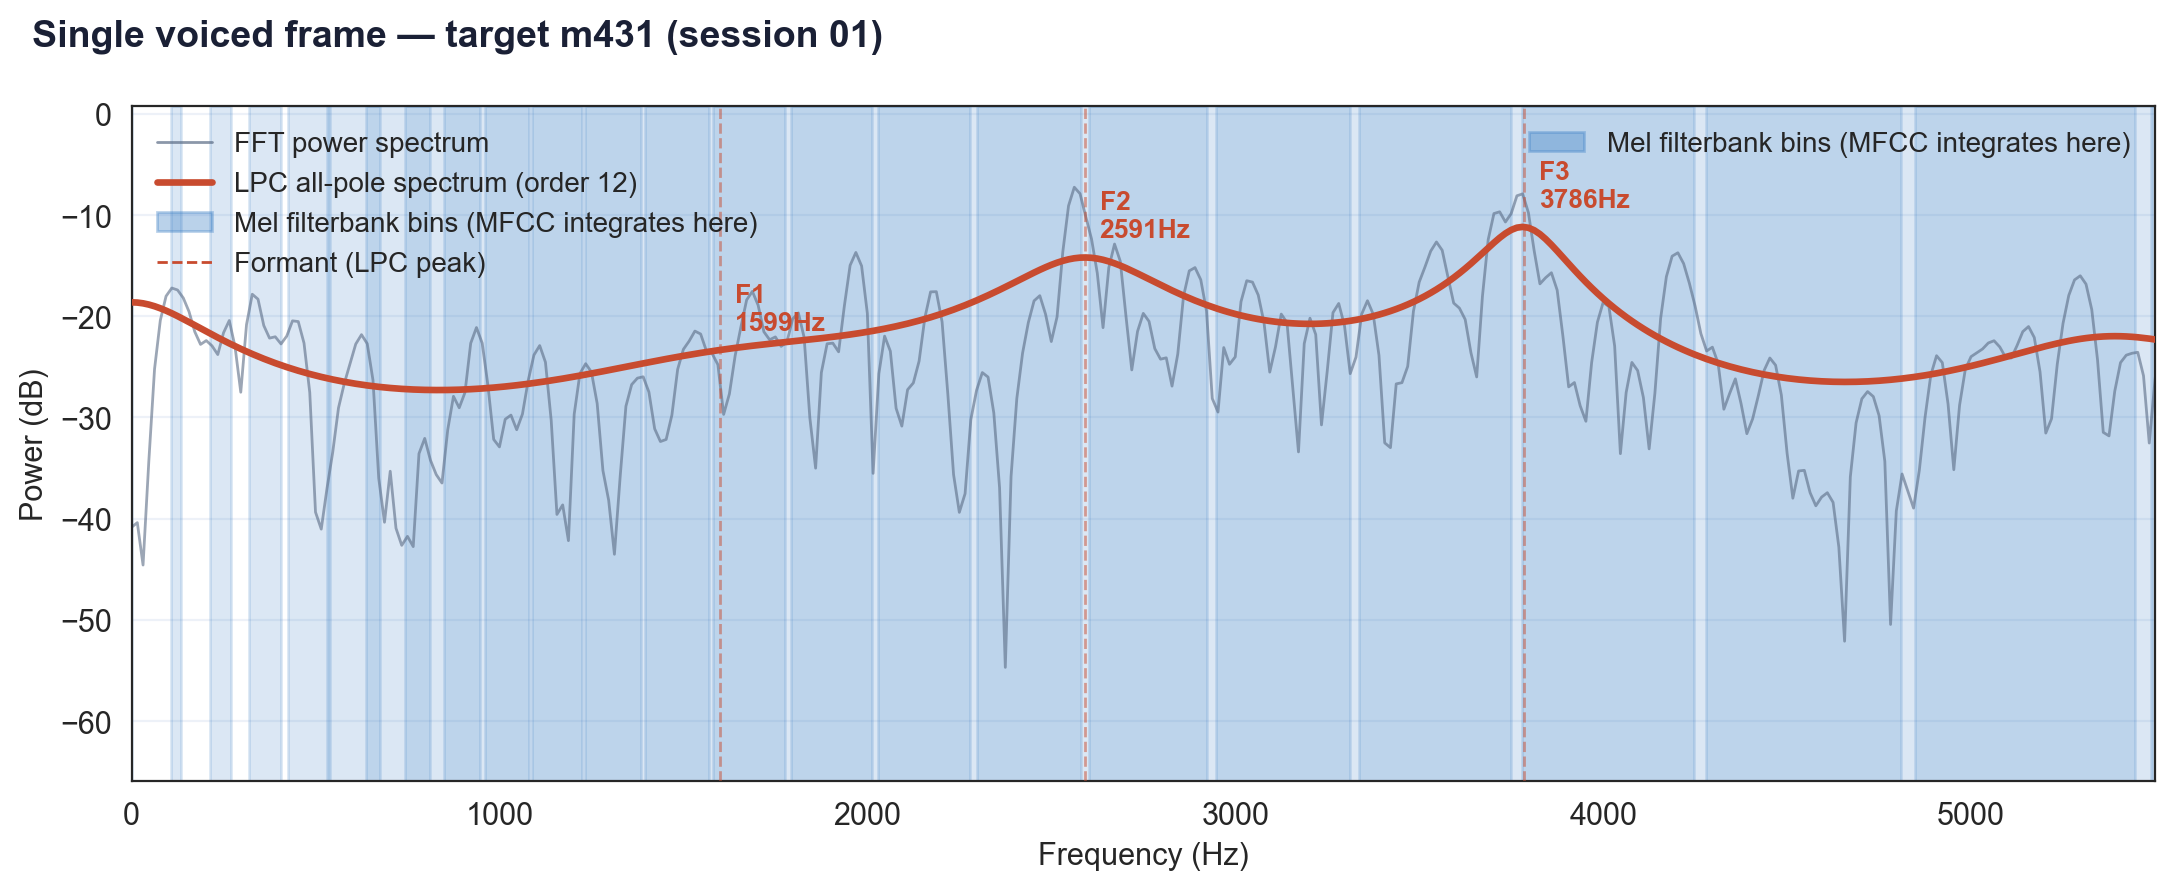

Formants: 1599Hz, 2591Hz, 3786Hz


In [4]:
# Pick a voiced frame from mid-utterance (avoid silence at edges)
ye      = preemphasis(y_tgt)
frames  = librosa.util.frame(ye, frame_length=WIN, hop_length=HOP).T
window  = np.hamming(WIN)

# Find a voiced frame: pick frame with highest energy in mid section
mid     = len(frames) // 4
energies = [np.sum(f**2) for f in frames[mid:mid*3]]
best    = mid + np.argmax(energies)
frame   = frames[best] * window

# FFT power spectrum
N_FFT = 1024
spec  = np.fft.rfft(frame, n=N_FFT)
freqs = np.fft.rfftfreq(N_FFT, 1/SR)
power_db = 20 * np.log10(np.abs(spec) + 1e-10)

# LPC spectrum
a, gain = lpc(frame, LPC_ORDER)
lpc_f, lpc_db = lpc_spectrum(a, gain, N_FFT)

# Formants
form_hz, form_bw = lpc_formants(a)
form_hz = form_hz[form_hz < 5000]   # keep up to 5kHz

# Mel filterbank (for overlay — show where each filter integrates)
mel_fb = librosa.filters.mel(sr=SR, n_fft=N_FFT, n_mels=26, fmin=0, fmax=SR//2)
mel_freqs_center = librosa.mel_frequencies(n_mels=26, fmin=0, fmax=SR//2)
spec_sq = np.abs(spec)**2  # power
mel_energies = mel_fb @ spec_sq

# ── Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5))

# FFT power spectrum
ax.plot(freqs, power_db, color=P["sub"], lw=1.0, alpha=0.6, label="FFT power spectrum", zorder=2)

# LPC all-pole spectrum
ax.plot(lpc_f, lpc_db, color=P["lpcc"], lw=2.4, label=f"LPC spectrum (order {LPC_ORDER})", zorder=4)

# Mel filter integration bands (show as shaded regions)
for i, (fc, energy) in enumerate(zip(mel_freqs_center, mel_energies)):
    # draw a short vertical tick at each filter centre, height = log energy
    e_db = 10 * np.log10(max(energy, 1e-10))
    alpha = 0.18
    ax.axvspan(fc * 0.88, fc * 1.12, alpha=alpha, color=P["mfcc"], zorder=1)
# legend proxy
from matplotlib.patches import Patch
mel_patch = Patch(color=P["mfcc"], alpha=0.35, label="Mel filterbank bins (MFCC integrates here)")
ax.add_artist(ax.legend(handles=[mel_patch], loc="upper right", fontsize=10))

# Formant markers
for i, (fz, bw) in enumerate(zip(form_hz, form_bw)):
    # find LPC dB at this frequency
    fidx = np.argmin(np.abs(lpc_f - fz))
    fdb  = lpc_db[fidx]
    ax.axvline(fz, color=P["lpcc"], lw=1.0, ls="--", alpha=0.5, zorder=3)
    ax.text(fz + 40, fdb + 1.5, f"F{i+1}\n{fz:.0f}Hz",
            color=P["lpcc"], fontsize=9.5, fontweight="bold", va="bottom")

ax.set_xlim(0, 5500)
ax.set_ylim(power_db.min() - 2, power_db.max() + 8)
ax.set_xlabel("Frequency (Hz)", fontsize=11)
ax.set_ylabel("Power (dB)", fontsize=11)
ax.yaxis.grid(True, color=P["grid"], lw=0.8, zorder=0)
ax.set_axisbelow(True)
handles = [
    plt.Line2D([0],[0], color=P["sub"],  lw=1.0, alpha=0.7, label="FFT power spectrum"),
    plt.Line2D([0],[0], color=P["lpcc"], lw=2.4, label=f"LPC all-pole spectrum (order {LPC_ORDER})"),
    mel_patch,
    plt.Line2D([0],[0], color=P["lpcc"], lw=1.0, ls="--", label="Formant (LPC peak)"),
]
ax.legend(handles=handles, loc="upper left", fontsize=10)
fig.suptitle("Single voiced frame — target m431 (session 01)",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
fig.tight_layout()
plt.savefig(PROJ / "docs/figures/analysis_a_single_frame.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Formants: {', '.join(f'{f:.0f}Hz' for f in form_hz)}")

## Fig B — Full utterance: waveform / spectrogram / MFCC / LPCC

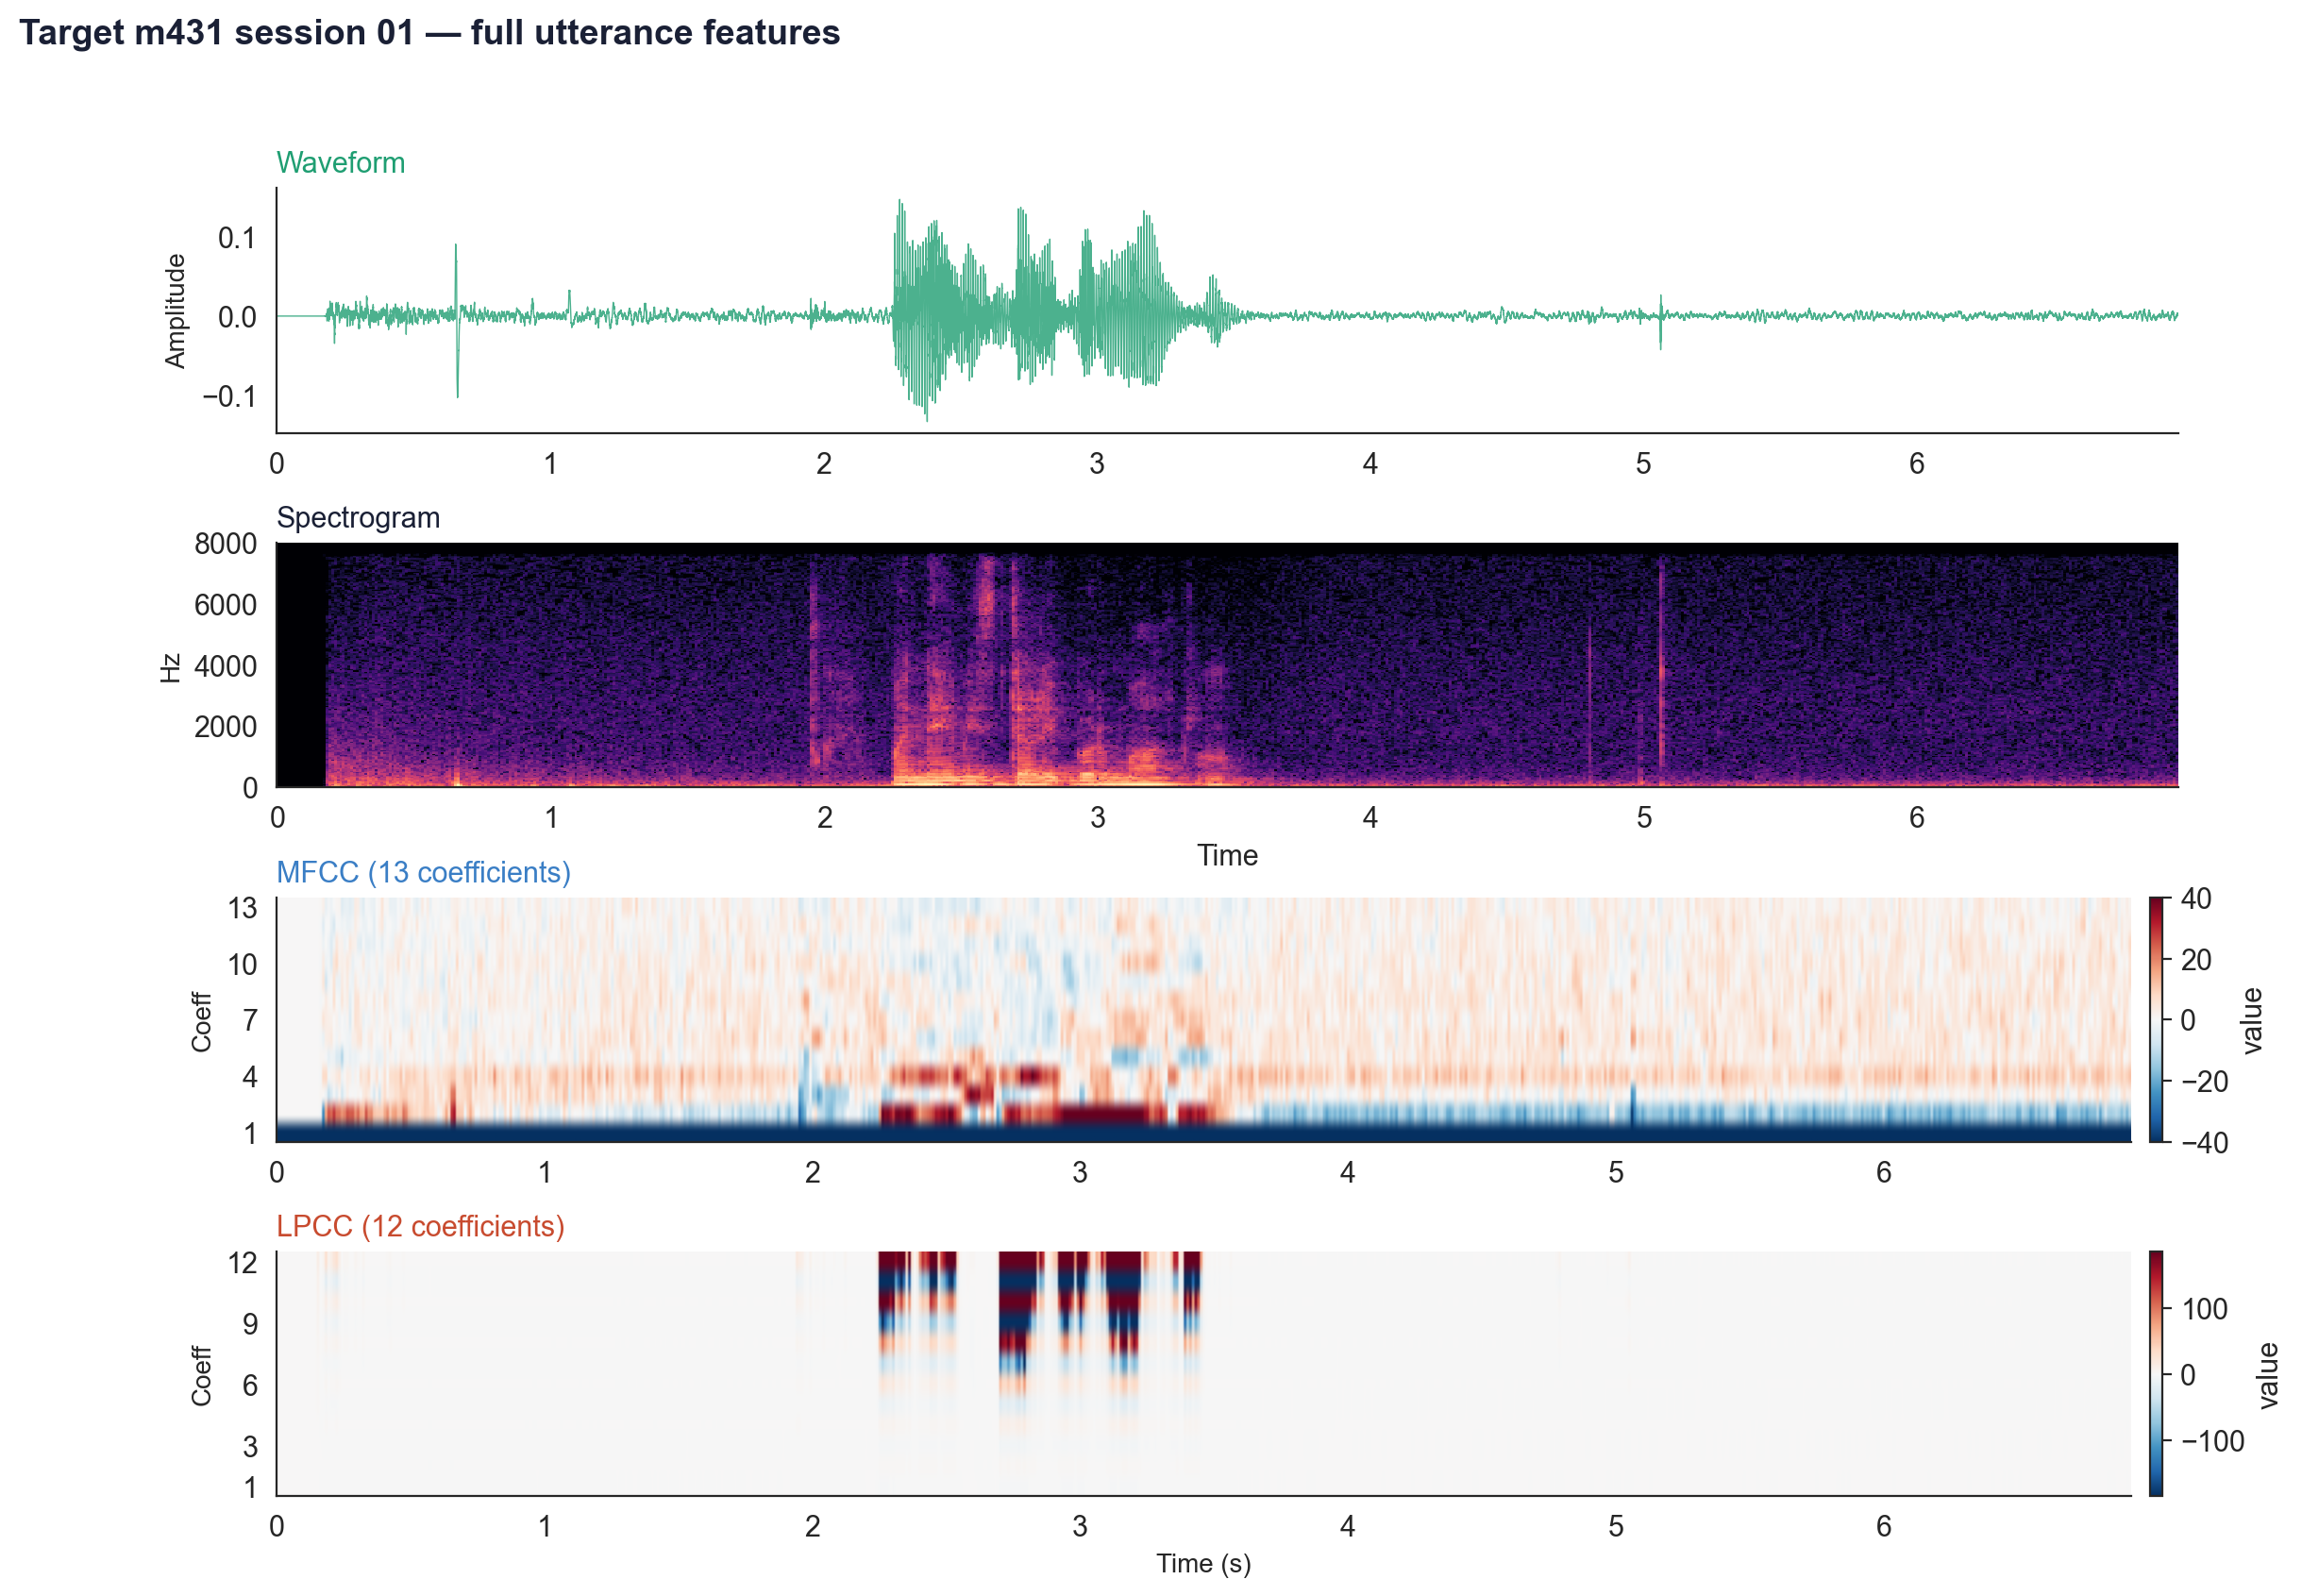

In [5]:
# Compute features for target s01
mfcc_tgt = extract_mfcc_frames(y_tgt)   # (T, 13)
lpcc_tgt = extract_lpcc_frames(y_tgt)   # (T, 12)
T = min(len(mfcc_tgt), len(lpcc_tgt))
mfcc_tgt = mfcc_tgt[:T]
lpcc_tgt = lpcc_tgt[:T]
t_axis   = np.arange(T) * HOP / SR

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# ── Waveform ────────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
t_wave = np.arange(len(y_tgt)) / SR
ax0.plot(t_wave, y_tgt, color=P["target"], lw=0.5, alpha=0.8)
ax0.set_ylabel("Amplitude", fontsize=10)
ax0.set_xlim(0, t_wave[-1])
ax0.spines["top"].set_visible(False); ax0.spines["right"].set_visible(False)
ax0.set_title("Waveform", fontsize=11, color=P["target"], loc="left")

# ── Spectrogram ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
D   = librosa.amplitude_to_db(np.abs(librosa.stft(y_tgt, n_fft=WIN, hop_length=HOP)), ref=np.max)
librosa.display.specshow(D, sr=SR, hop_length=HOP, x_axis="time", y_axis="hz",
                          ax=ax1, cmap="magma")
ax1.set_ylim(0, SR//2)
ax1.set_ylabel("Hz", fontsize=10)
ax1.set_title("Spectrogram", fontsize=11, color=P["ink"], loc="left")
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)

# ── MFCC ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
im2 = ax2.imshow(mfcc_tgt.T, aspect="auto", origin="lower",
                 extent=[0, t_axis[-1], 0.5, N_MFCC + 0.5],
                 cmap="RdBu_r", vmin=-40, vmax=40)
ax2.set_ylabel("Coeff", fontsize=10)
ax2.set_yticks([1, 4, 7, 10, 13])
ax2.set_title("MFCC (13 coefficients)", fontsize=11, color=P["mfcc"], loc="left")
plt.colorbar(im2, ax=ax2, pad=0.01, fraction=0.015, label="value")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# ── LPCC ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[3])
vmax = np.percentile(np.abs(lpcc_tgt), 98)
im3  = ax3.imshow(lpcc_tgt.T, aspect="auto", origin="lower",
                  extent=[0, t_axis[-1], 0.5, LPC_ORDER + 0.5],
                  cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax3.set_ylabel("Coeff", fontsize=10)
ax3.set_yticks([1, 3, 6, 9, 12])
ax3.set_xlabel("Time (s)", fontsize=10)
ax3.set_title("LPCC (12 coefficients)", fontsize=11, color=P["lpcc"], loc="left")
plt.colorbar(im3, ax=ax3, pad=0.01, fraction=0.015, label="value")
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

fig.suptitle("Target m431 session 01 — full utterance features",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
plt.savefig(PROJ / "docs/figures/analysis_b_feature_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig C — Codec destruction (8 kHz bandwidth limit)

What happens to the spectrum and features when audio is resampled to 8kHz and back.

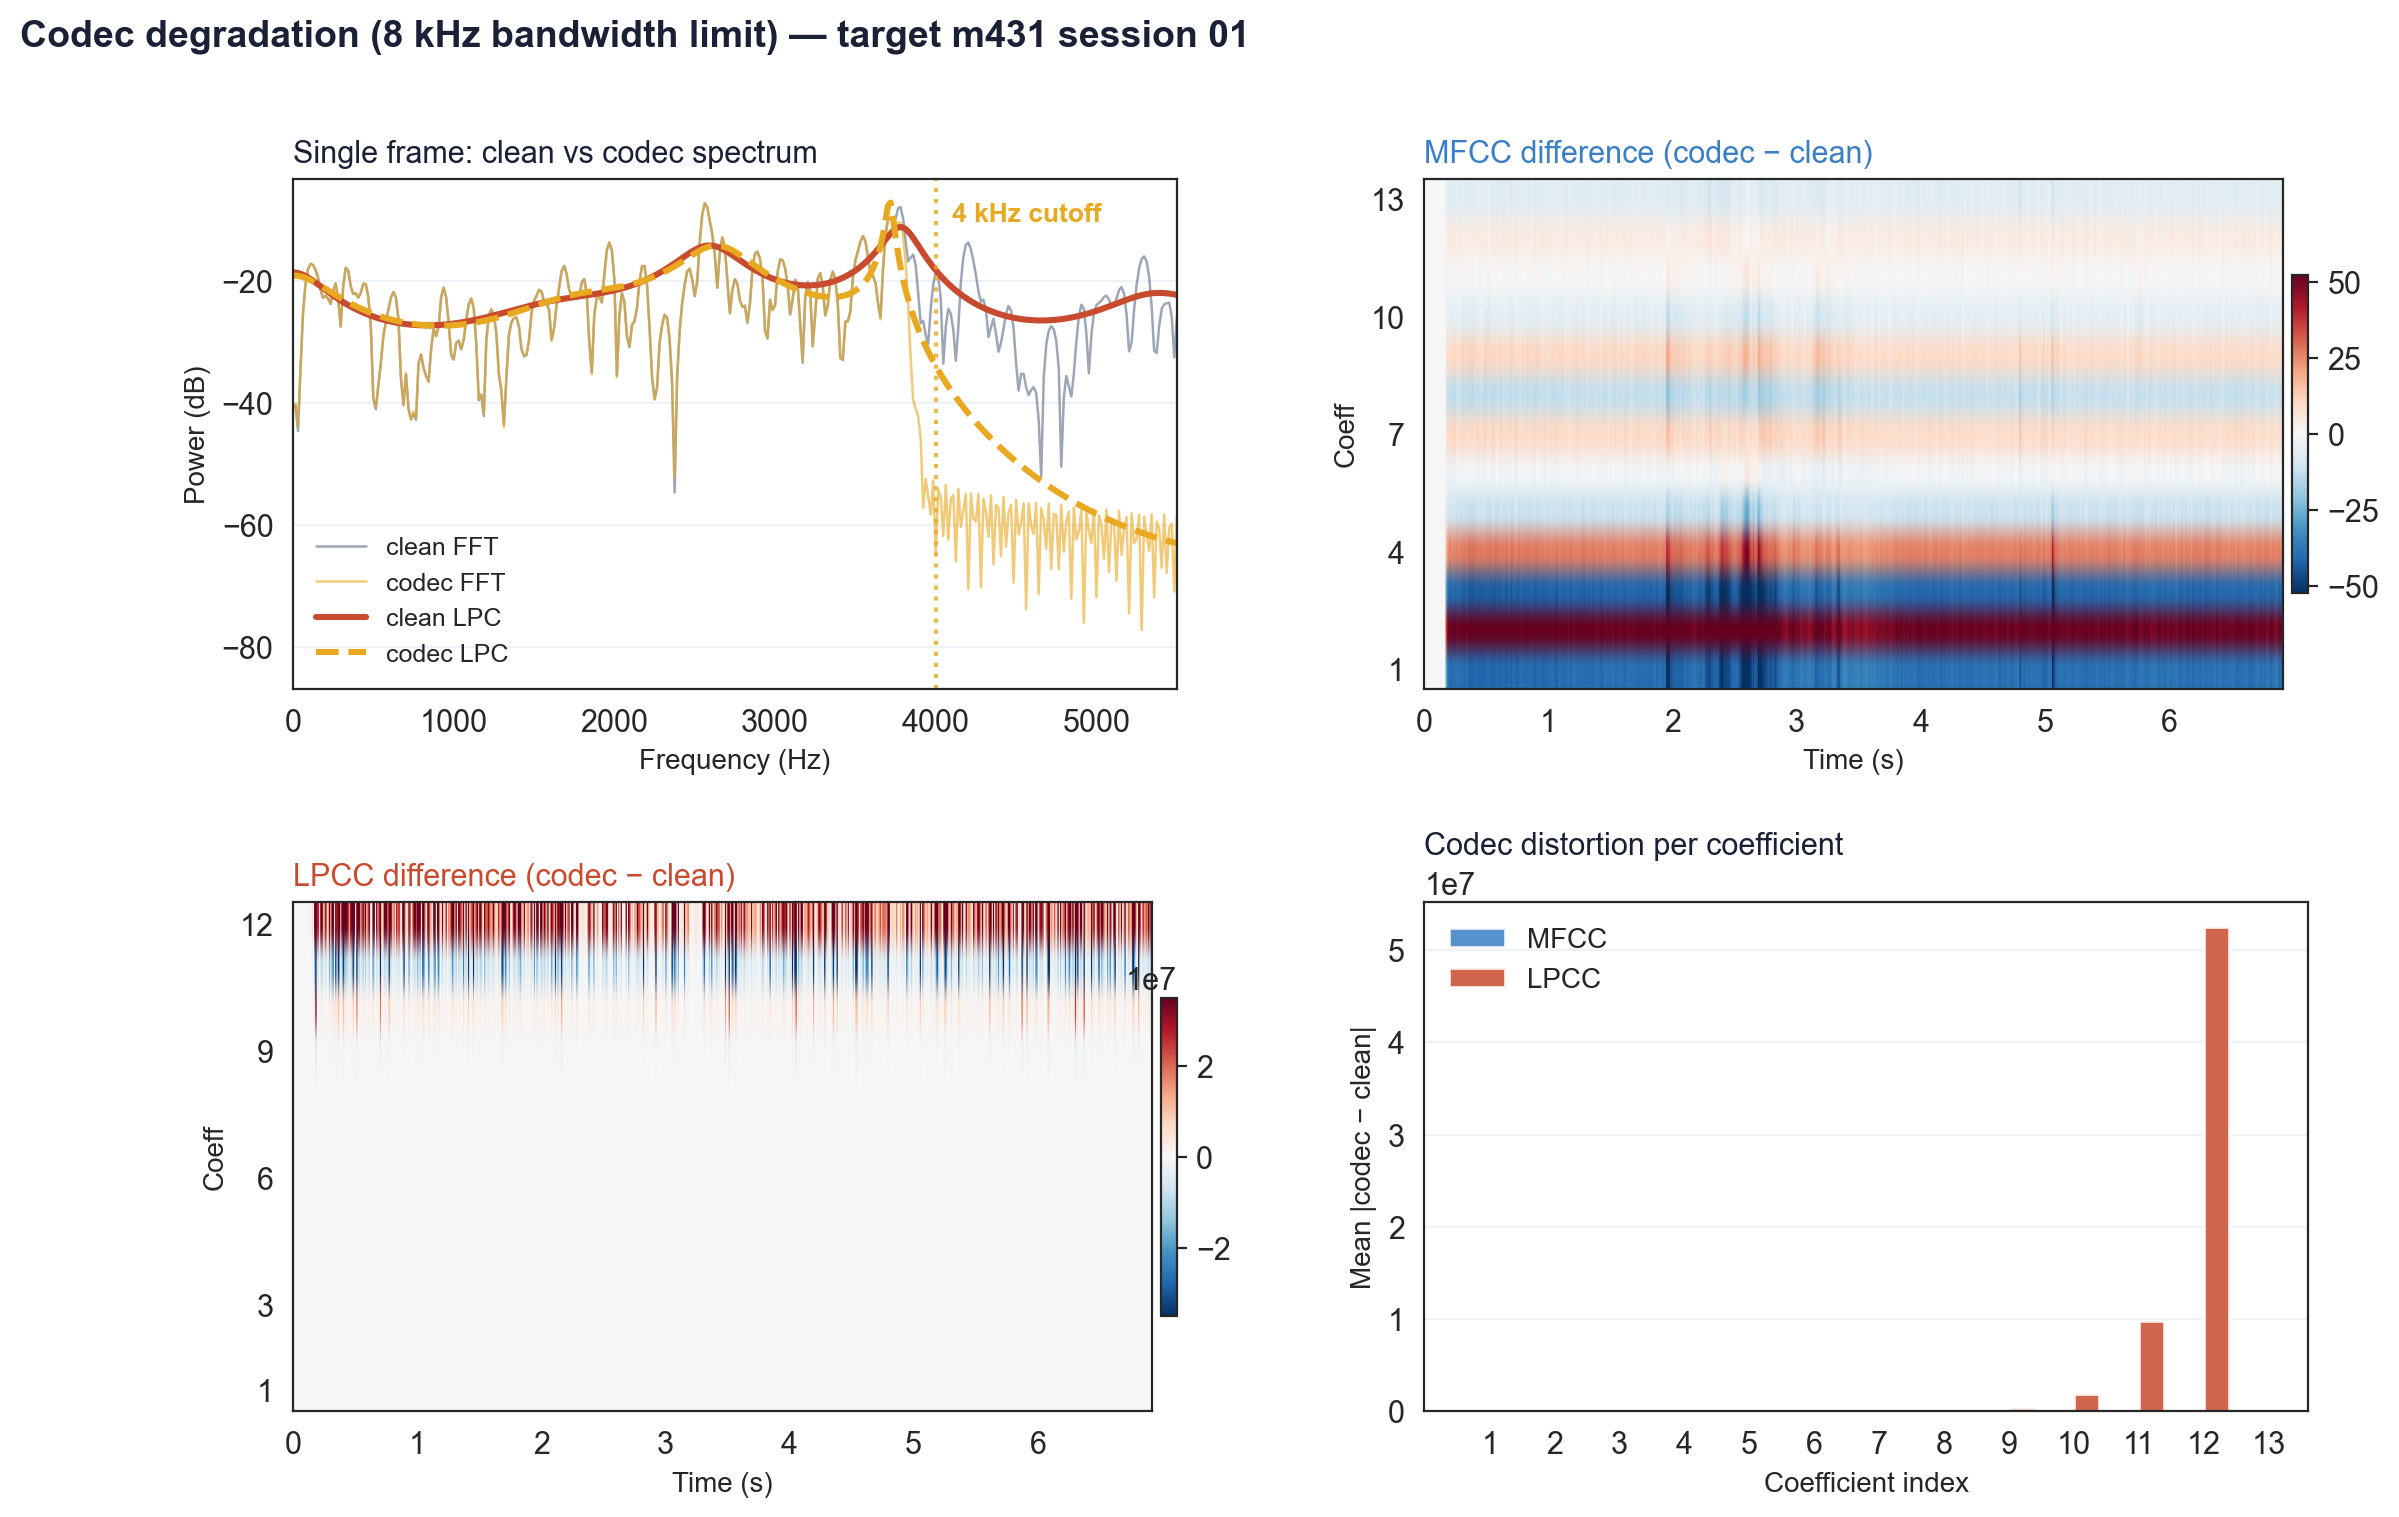

In [6]:
y_codec = codec_degrade(y_tgt)

mfcc_clean = extract_mfcc_frames(y_tgt)
mfcc_codec = extract_mfcc_frames(y_codec)
lpcc_clean = extract_lpcc_frames(y_tgt)
lpcc_codec = extract_lpcc_frames(y_codec)

Tc = min(len(mfcc_clean), len(mfcc_codec), len(lpcc_clean), len(lpcc_codec))
mfcc_clean = mfcc_clean[:Tc]; mfcc_codec = mfcc_codec[:Tc]
lpcc_clean = lpcc_clean[:Tc]; lpcc_codec = lpcc_codec[:Tc]

# Also get single-frame spectra (same voiced frame as before)
frame_codec = librosa.util.frame(preemphasis(y_codec) * 1.0,
                                 frame_length=WIN, hop_length=HOP).T
if best < len(frame_codec):
    fr_c = frame_codec[best] * window
    ac, gc = lpc(fr_c, LPC_ORDER)
    lpc_fc, lpc_dbc = lpc_spectrum(ac, gc, N_FFT)
    spec_c  = np.fft.rfft(fr_c, n=N_FFT)
    power_dbc = 20 * np.log10(np.abs(spec_c) + 1e-10)
else:
    lpc_fc, lpc_dbc = lpc_f, lpc_db
    power_dbc = power_db

fig, axes = plt.subplots(2, 2, figsize=(13, 8), gridspec_kw=dict(hspace=0.42, wspace=0.28))

# ── Top-left: spectra comparison ─────────────────────────────────────────
ax = axes[0, 0]
ax.plot(freqs, power_db,  color=P["sub"],    lw=0.9, alpha=0.6, label="clean FFT")
ax.plot(freqs, power_dbc, color=P["codec"],  lw=0.9, alpha=0.6, label="codec FFT")
ax.plot(lpc_f, lpc_db,   color=P["lpcc"],   lw=2.2, label="clean LPC")
ax.plot(lpc_fc, lpc_dbc, color=P["codec"],  lw=2.2, ls="--", label="codec LPC")
ax.axvline(4000, color=P["codec"], lw=1.5, ls=":", alpha=0.8)
ax.text(4100, power_db.max() - 3, "4 kHz cutoff", color=P["codec"],
        fontsize=9.5, fontweight="bold")
ax.set_xlim(0, 5500)
ax.set_xlabel("Frequency (Hz)", fontsize=10)
ax.set_ylabel("Power (dB)", fontsize=10)
ax.legend(fontsize=9, loc="lower left")
ax.yaxis.grid(True, color=P["grid"], lw=0.7); ax.set_axisbelow(True)
ax.set_title("Single frame: clean vs codec spectrum", fontsize=11, color=P["ink"], loc="left")

# ── Top-right: MFCC difference ────────────────────────────────────────────
ax = axes[0, 1]
diff_mfcc = mfcc_codec - mfcc_clean
vmax = np.percentile(np.abs(diff_mfcc), 97)
t_ax = np.arange(Tc) * HOP / SR
im = ax.imshow(diff_mfcc.T, aspect="auto", origin="lower",
               extent=[0, t_ax[-1], 0.5, N_MFCC + 0.5],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, pad=0.01, fraction=0.018)
ax.set_xlabel("Time (s)", fontsize=10); ax.set_ylabel("Coeff", fontsize=10)
ax.set_yticks([1, 4, 7, 10, 13])
ax.set_title("MFCC difference (codec − clean)", fontsize=11, color=P["mfcc"], loc="left")

# ── Bottom-left: LPCC difference ──────────────────────────────────────────
ax = axes[1, 0]
diff_lpcc = lpcc_codec - lpcc_clean
vmax2 = np.percentile(np.abs(diff_lpcc), 97)
im2 = ax.imshow(diff_lpcc.T, aspect="auto", origin="lower",
                extent=[0, t_ax[-1], 0.5, LPC_ORDER + 0.5],
                cmap="RdBu_r", vmin=-vmax2, vmax=vmax2)
plt.colorbar(im2, ax=ax, pad=0.01, fraction=0.018)
ax.set_xlabel("Time (s)", fontsize=10); ax.set_ylabel("Coeff", fontsize=10)
ax.set_yticks([1, 3, 6, 9, 12])
ax.set_title("LPCC difference (codec − clean)", fontsize=11, color=P["lpcc"], loc="left")

# ── Bottom-right: mean absolute difference per coefficient ────────────────
ax = axes[1, 1]
mad_mfcc = np.mean(np.abs(diff_mfcc), axis=0)
mad_lpcc = np.mean(np.abs(diff_lpcc), axis=0)
x_m = np.arange(1, N_MFCC + 1)
x_l = np.arange(1, LPC_ORDER + 1)
ax.bar(x_m - 0.2, mad_mfcc, 0.38, color=P["mfcc"], alpha=0.85, label="MFCC")
ax.bar(x_l + 0.2, mad_lpcc, 0.38, color=P["lpcc"], alpha=0.85, label="LPCC")
ax.set_xlabel("Coefficient index", fontsize=10)
ax.set_ylabel("Mean |codec − clean|", fontsize=10)
ax.set_xticks(x_m)
ax.legend(fontsize=10)
ax.yaxis.grid(True, color=P["grid"], lw=0.7); ax.set_axisbelow(True)
ax.set_title("Codec distortion per coefficient", fontsize=11, color=P["ink"], loc="left")

fig.suptitle("Codec degradation (8 kHz bandwidth limit) — target m431 session 01",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
plt.savefig(PROJ / "docs/figures/analysis_c_codec.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig D — Covariance structure: why LPCC needs tied covariance

MFCC (DCT-decorrelated) vs LPCC (cepstral recursion introduces correlations).

Total frames: MFCC (26073, 13), LPCC (25999, 12)


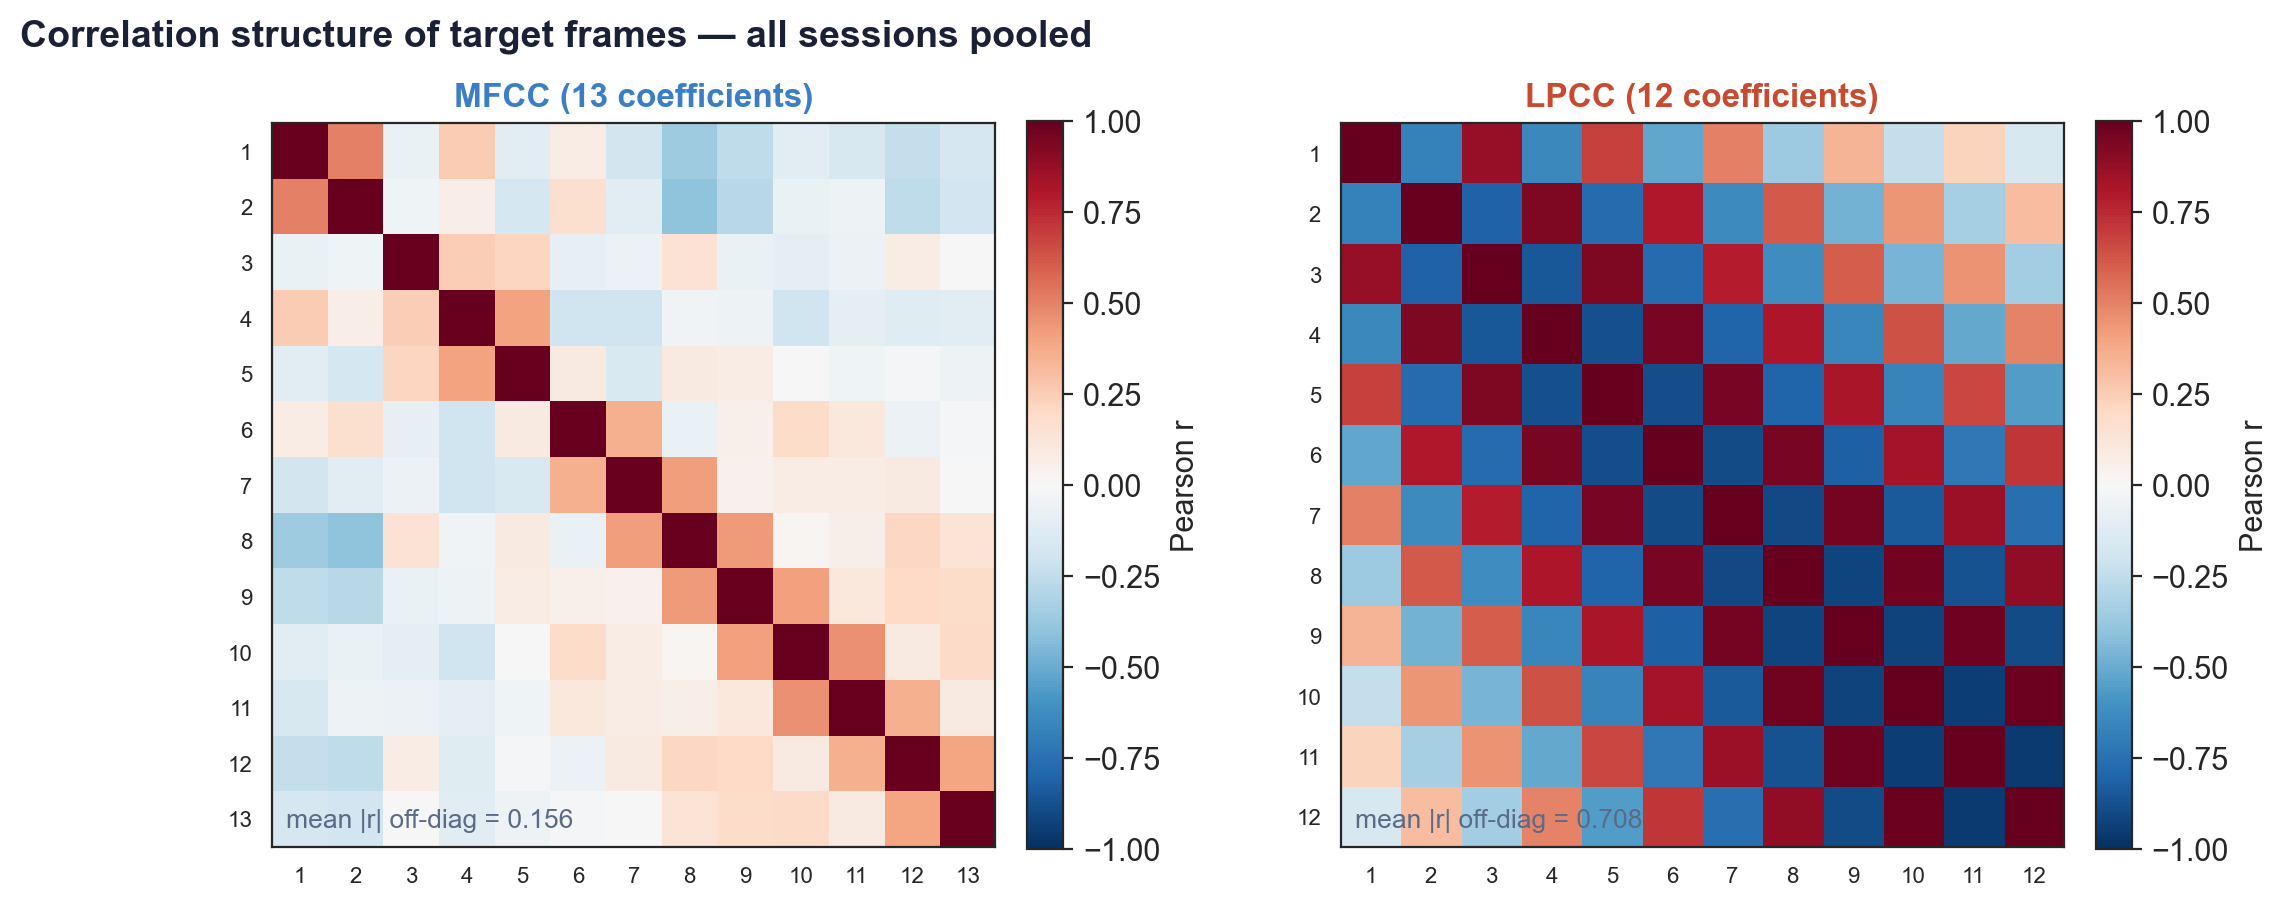

In [7]:
# Pool all target training frames
all_mfcc, all_lpcc = [], []
for wav in (glob.glob(str(DATA / "target_train" / "*.wav")) +
            glob.glob(str(DATA / "target_dev"   / "*.wav"))):
    y, _ = librosa.load(wav, sr=SR)
    all_mfcc.append(extract_mfcc_frames(y))
    all_lpcc.append(extract_lpcc_frames(y))

all_mfcc = np.vstack(all_mfcc)
all_lpcc = np.vstack(all_lpcc)
print(f"Total frames: MFCC {all_mfcc.shape}, LPCC {all_lpcc.shape}")

# Correlation matrices (normalised covariance)
corr_mfcc = np.corrcoef(all_mfcc.T)
corr_lpcc = np.corrcoef(all_lpcc.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw=dict(wspace=0.35))

for ax, corr, title, col in [
        (axes[0], corr_mfcc, f"MFCC ({N_MFCC} coefficients)", P["mfcc"]),
        (axes[1], corr_lpcc, f"LPCC ({LPC_ORDER} coefficients)", P["lpcc"]),
]:
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
    n = corr.shape[0]
    ax.set_xticks(range(n)); ax.set_xticklabels(range(1, n+1), fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(range(1, n+1), fontsize=8)
    ax.set_title(title, fontsize=12, color=col, fontweight="semibold")

    # Print mean off-diagonal absolute correlation
    mask = ~np.eye(n, dtype=bool)
    mean_r = np.mean(np.abs(corr[mask]))
    ax.text(0.02, 0.02, f"mean |r| off-diag = {mean_r:.3f}",
            transform=ax.transAxes, fontsize=9.5, color=P["sub"],
            va="bottom")

fig.suptitle("Correlation structure of target frames — all sessions pooled",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
plt.savefig(PROJ / "docs/figures/analysis_d_covariance.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig E — LPCC frame PCA: target sessions vs non-target speakers

Shows speaker discriminability and session variability.

/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/545203927.py:102: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  plt.savefig(PROJ / "docs/figures/analysis_e_pca.png", dpi=150, bbox_inches="tight")
/Users/ramsay/school/sur/project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


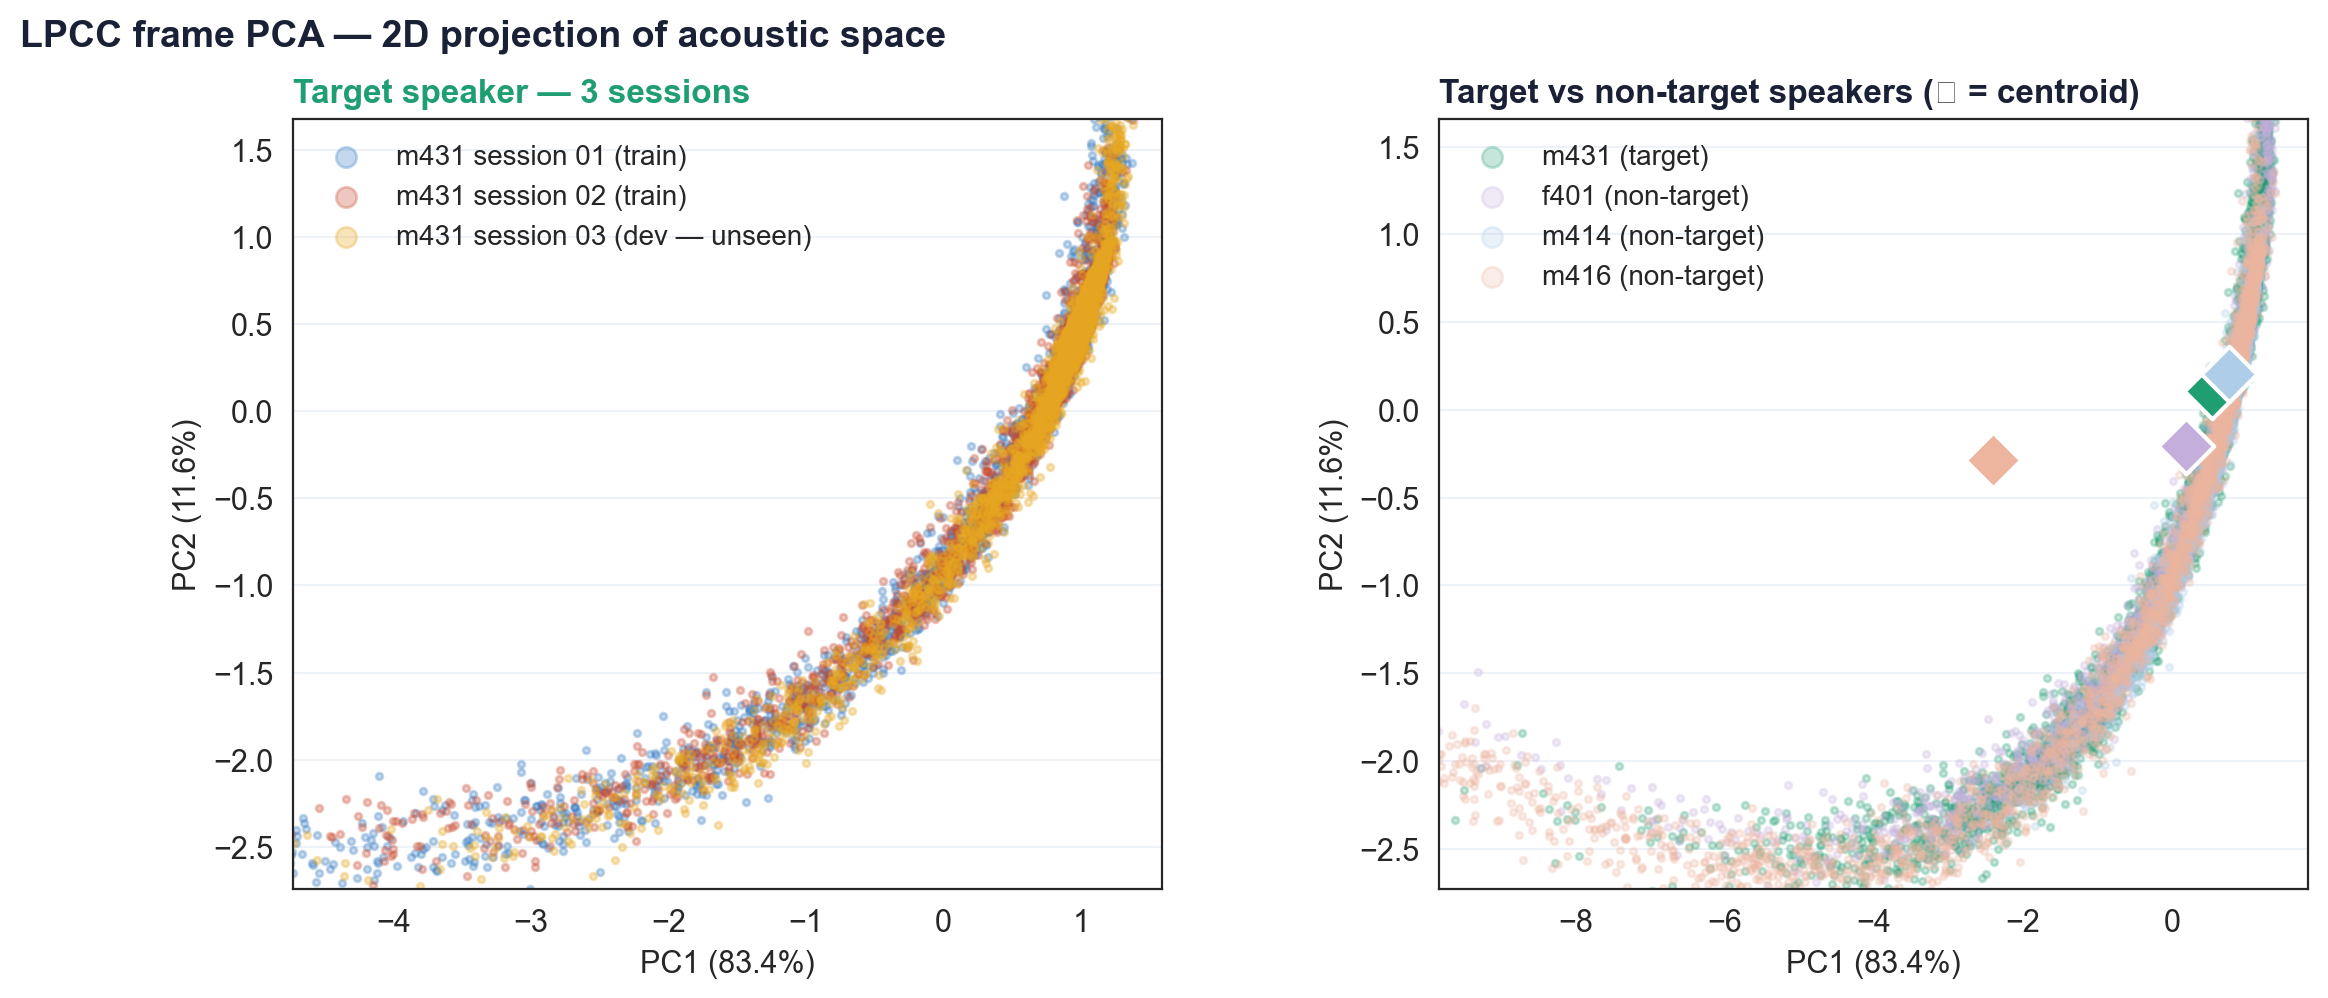

In [8]:
# Collect frames per group (subsample for speed)
def get_frames(wavs, n_per=400):
    out = []
    for w in wavs:
        y, _ = librosa.load(w, sr=SR)
        f = extract_lpcc_frames(y)
        # Drop extreme frames (silence / glitches) by L2-norm percentile
        norms = np.linalg.norm(f, axis=1)
        lo, hi = np.percentile(norms, 5), np.percentile(norms, 95)
        f = f[(norms >= lo) & (norms <= hi)]
        if len(f) > n_per:
            rng_idx = np.random.choice(len(f), n_per, replace=False)
            f = f[rng_idx]
        if len(f) > 0:
            out.append(f)
    return np.vstack(out)

np.random.seed(42)
s01_wavs = [f for f in glob.glob(str(DATA / "target_train" / "*.wav")) if "_01_" in Path(f).name]
s02_wavs = [f for f in glob.glob(str(DATA / "target_train" / "*.wav")) if "_02_" in Path(f).name]
s03_wavs = glob.glob(str(DATA / "target_dev"   / "*.wav"))
f401_wavs = glob.glob(str(DATA / "non_target_train" / "f401*.wav"))
m414_wavs = glob.glob(str(DATA / "non_target_train" / "m414*.wav"))
m416_wavs = glob.glob(str(DATA / "non_target_train" / "m416*.wav"))

frames_s01  = get_frames(s01_wavs)
frames_s02  = get_frames(s02_wavs)
frames_s03  = get_frames(s03_wavs)
frames_f401 = get_frames(f401_wavs)
frames_m414 = get_frames(m414_wavs)
frames_m416 = get_frames(m416_wavs)

all_frames = np.vstack([frames_s01, frames_s02, frames_s03,
                        frames_f401, frames_m414, frames_m416])

# Standardise per-coefficient before PCA — prevents silent-frame outliers
# from collapsing 99.9% of variance into one trivial direction.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(all_frames)
all_norm = scaler.transform(all_frames)
pca = PCA(n_components=2).fit(all_norm)
var = pca.explained_variance_ratio_ * 100

def proj(X): return pca.transform(scaler.transform(X))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw=dict(wspace=0.32))

# ── Left: target sessions ────────────────────────────────────────────────────
ax = axes[0]
tgt_groups = [
    (frames_s01, P["s01"], "m431 session 01 (train)"),
    (frames_s02, P["s02"], "m431 session 02 (train)"),
    (frames_s03, P["s03"], "m431 session 03 (dev — unseen)"),
]
all_tgt = np.vstack([proj(f) for f, _, _ in tgt_groups])
for frames, col, lbl in tgt_groups:
    p = proj(frames)
    ax.scatter(p[:, 0], p[:, 1], c=col, s=6, alpha=0.30, label=lbl, rasterized=True)
# Zoom to dense region
x1, x2 = np.percentile(all_tgt[:,0], [1, 99])
y1, y2 = np.percentile(all_tgt[:,1], [1, 99])
px, py  = (x2-x1)*0.06, (y2-y1)*0.06
ax.set_xlim(x1-px, x2+px); ax.set_ylim(y1-py, y2+py)
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)", fontsize=11)
ax.legend(fontsize=10, markerscale=3)
ax.yaxis.grid(True, color=P["grid"], lw=0.7); ax.set_axisbelow(True)
ax.set_title("Target speaker — 3 sessions", fontsize=12,
             color=P["target"], fontweight="semibold", loc="left")

# ── Right: target vs non-target ──────────────────────────────────────────────
ax = axes[1]
all_groups = [
    (np.vstack([frames_s01, frames_s02, frames_s03]), P["target"], "m431 (target)"),
    (frames_f401, "#C4AFDC", "f401 (non-target)"),
    (frames_m414, "#AECDE8", "m414 (non-target)"),
    (frames_m416, "#EDB49E", "m416 (non-target)"),
]
all_proj = np.vstack([proj(f) for f, _, _ in all_groups])
for frames, col, lbl in all_groups:
    p = proj(frames)
    ax.scatter(p[:, 0], p[:, 1], c=col, s=6, alpha=0.25, label=lbl, rasterized=True)
# Mark centroids
for frames, col, _ in all_groups:
    p = proj(frames)
    ax.scatter(p[:,0].mean(), p[:,1].mean(), c=col, s=200,
               edgecolors="white", linewidths=1.5, zorder=5, marker="D")
# Zoom to 2–98 percentile
x1, x2 = np.percentile(all_proj[:,0], [2, 98])
y1, y2 = np.percentile(all_proj[:,1], [2, 98])
px, py  = (x2-x1)*0.06, (y2-y1)*0.06
ax.set_xlim(x1-px, x2+px); ax.set_ylim(y1-py, y2+py)
ax.set_xlabel(f"PC1 ({var[0]:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]:.1f}%)", fontsize=11)
ax.legend(fontsize=10, markerscale=3)
ax.yaxis.grid(True, color=P["grid"], lw=0.7); ax.set_axisbelow(True)
ax.set_title("Target vs non-target speakers (◆ = centroid)", fontsize=12,
             color=P["ink"], fontweight="semibold", loc="left")

fig.suptitle("LPCC frame PCA — 2D projection of acoustic space",
             x=0.02, ha="left", fontsize=13.5, fontweight="semibold", color=P["ink"])
plt.savefig(PROJ / "docs/figures/analysis_e_pca.png", dpi=150, bbox_inches="tight")
plt.show()


### Done — 5 analysis figures saved to `docs/figures/`.

## Fig F — Audio vs Image complementarity

Platt-calibrated OOF scores on two axes. Quadrants show where each modality agrees/disagrees. Fusion rescues the off-diagonal failures.

In [9]:
import pickle
from sklearn.metrics import roc_curve
import sys; sys.path.insert(0, "..")

CACHE = PROJ / "cache"
with open(CACHE / "oof_scores.pkl", "rb") as fh:
    scores = pickle.load(fh)

y      = scores["y"]
s_lpcc = scores["lpcc"]
s_img  = scores["image"]
s_fus  = scores["fusion"]

# EER thresholds (optimal operating point for each system)
def eer_thr(score, y):
    fpr, tpr, thr = roc_curve(y, score)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(thr[min(idx, len(thr)-1)])

thr_a = eer_thr(s_lpcc, y)
thr_i = eer_thr(s_img,  y)
thr_f = eer_thr(s_fus,  y)

pred_a = (s_lpcc >= thr_a).astype(int)
pred_i = (s_img  >= thr_i).astype(int)
pred_f = (s_fus  >= thr_f).astype(int)

ok_a = pred_a == y;  ok_i = pred_i == y;  ok_f = pred_f == y
n = len(y)

cats = {
    "both correct":              (ok_a  & ok_i).sum(),
    "audio ✓  image ✗":         (ok_a  & ~ok_i).sum(),
    "audio ✗  image ✓":         (~ok_a & ok_i).sum(),
    "both wrong":                (~ok_a & ~ok_i).sum(),
}
print("Complementarity breakdown:")
for k, v in cats.items():
    print(f"  {k}: {v}/{n}  ({100*v/n:.1f}%)")
print(f"\nFusion errors: {(~ok_f).sum()}/{n}")
print(f"Thresholds — audio: {thr_a:.3f}  image: {thr_i:.3f}  fusion: {thr_f:.3f}")


Complementarity breakdown:
  both correct: 202/222  (91.0%)
  audio ✓  image ✗: 15/222  (6.8%)
  audio ✗  image ✓: 5/222  (2.3%)
  both wrong: 0/222  (0.0%)

Fusion errors: 0/222
Thresholds — audio: 1.439  image: 0.073  fusion: 0.685


/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/636789151.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


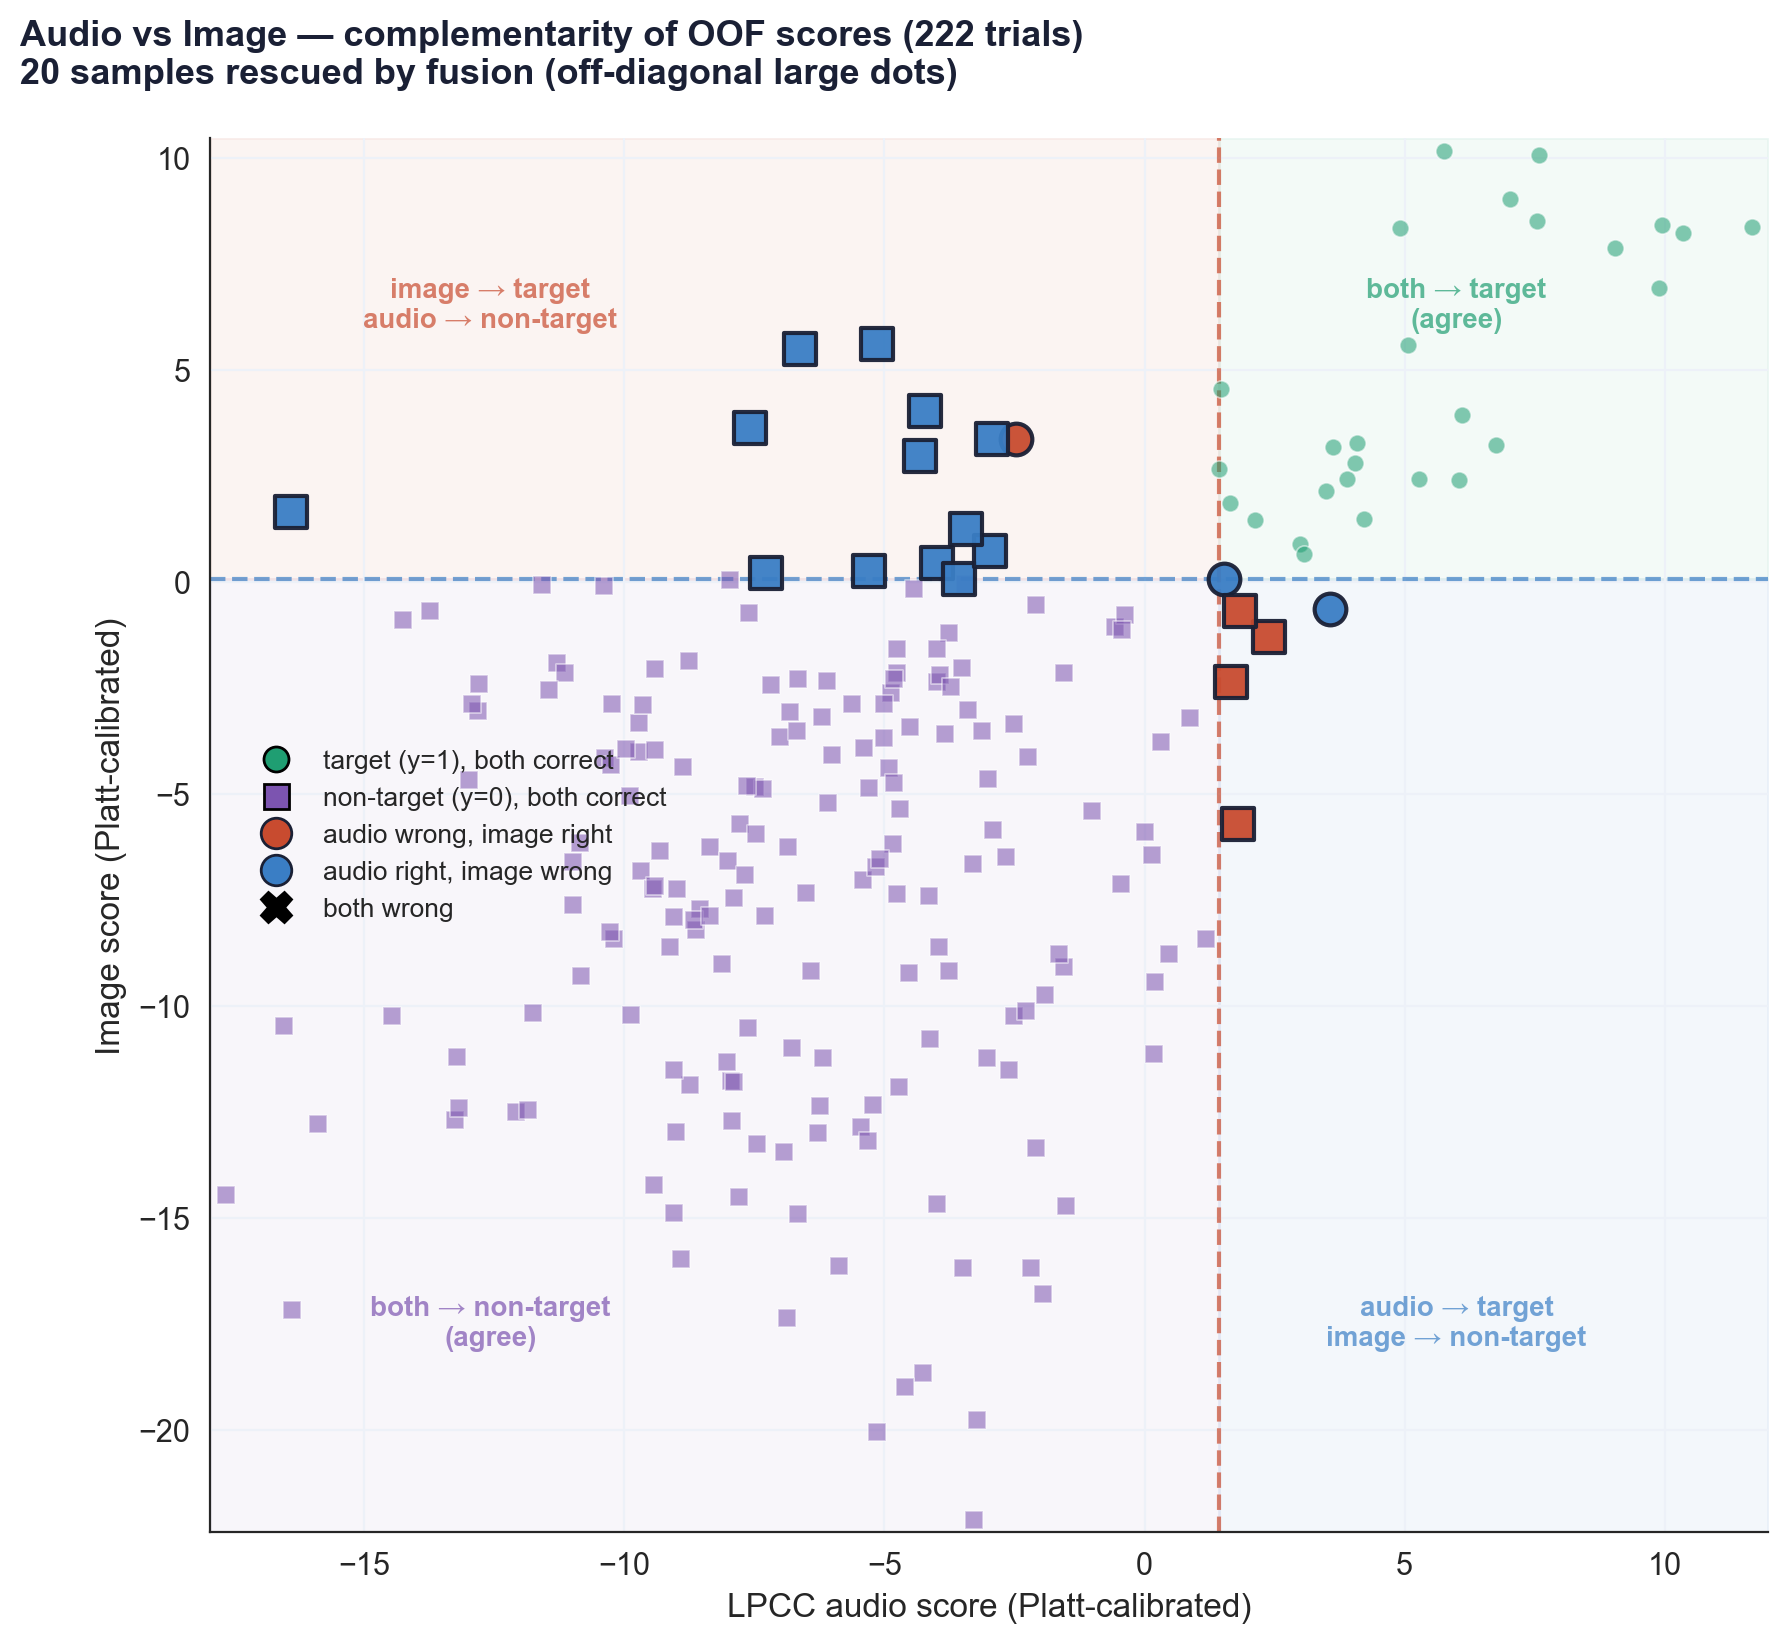

In [10]:
# ── Scatter: audio score vs image score ─────────────────────────────────────
fig = plt.figure(figsize=(9.5, 8.5))
ax  = fig.add_axes([0.12, 0.12, 0.82, 0.82])

# Quadrant shading (very subtle)
xmin, xmax = s_lpcc.min()-0.3, s_lpcc.max()+0.3
ymin, ymax = s_img.min()-0.3,  s_img.max()+0.3
ax.fill_between([thr_a, xmax], thr_i, ymax, color=P["target"],    alpha=0.05, zorder=0)  # Q1: both say target
ax.fill_between([xmin, thr_a], ymin,  thr_i, color=P["nontgt"],   alpha=0.05, zorder=0)  # Q3: both say non-target
ax.fill_between([xmin, thr_a], thr_i, ymax,  color=P["s02"],      alpha=0.06, zorder=0)  # Q2: audio wrong, image right
ax.fill_between([thr_a, xmax], ymin,  thr_i, color=P["s01"],      alpha=0.06, zorder=0)  # Q4: audio right, image wrong

# Decision boundary lines
ax.axvline(thr_a, color=P["lpcc"],  lw=1.5, ls="--", alpha=0.7, label=f"audio threshold ({thr_a:.2f})")
ax.axhline(thr_i, color=P["mfcc"], lw=1.5, ls="--", alpha=0.7, label=f"image threshold ({thr_i:.2f})")

# Points: shape = target/non-target,  color = correct/wrong
for label, marker, zord in [(1, "o", 4), (0, "s", 3)]:
    mask = y == label
    col_base = P["target"] if label == 1 else P["nontgt"]

    # Correct predictions (both agree)
    both_ok = mask & ok_a & ok_i
    ax.scatter(s_lpcc[both_ok], s_img[both_ok], c=col_base, s=38,
               marker=marker, alpha=0.55, edgecolors="white", lw=0.6, zorder=zord)

    # Audio wrong, image right
    a_bad = mask & ~ok_a & ok_i
    if a_bad.any():
        ax.scatter(s_lpcc[a_bad], s_img[a_bad], c=P["s02"], s=130,
                   marker=marker, alpha=0.95, edgecolors=P["ink"], lw=1.5, zorder=6)

    # Audio right, image wrong
    i_bad = mask & ok_a & ~ok_i
    if i_bad.any():
        ax.scatter(s_lpcc[i_bad], s_img[i_bad], c=P["s01"], s=130,
                   marker=marker, alpha=0.95, edgecolors=P["ink"], lw=1.5, zorder=6)

    # Both wrong
    both_bad = mask & ~ok_a & ~ok_i
    if both_bad.any():
        ax.scatter(s_lpcc[both_bad], s_img[both_bad], c="black", s=180,
                   marker="X", alpha=0.95, edgecolors="white", lw=1.2, zorder=7)

# Quadrant labels
def qlabel(ax, x, y, txt, col, fs=10):
    ax.text(x, y, txt, transform=ax.transAxes, fontsize=fs,
            color=col, ha="center", va="center", alpha=0.7,
            fontweight="semibold")

qlabel(ax, 0.80, 0.88, "both → target\n(agree)", P["target"])
qlabel(ax, 0.18, 0.15, "both → non-target\n(agree)", P["nontgt"])
qlabel(ax, 0.18, 0.88, "image → target\naudio → non-target", P["s02"])
qlabel(ax, 0.80, 0.15, "audio → target\nimage → non-target", P["s01"])

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_els = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor=P["target"],
           markersize=9, label="target (y=1), both correct"),
    Line2D([0],[0], marker="s", color="none", markerfacecolor=P["nontgt"],
           markersize=9, label="non-target (y=0), both correct"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor=P["s02"],
           markeredgecolor=P["ink"], markersize=11, label="audio wrong, image right"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor=P["s01"],
           markeredgecolor=P["ink"], markersize=11, label="audio right, image wrong"),
    Line2D([0],[0], marker="X", color="none", markerfacecolor="black",
           markersize=11, label="both wrong"),
]
ax.legend(handles=legend_els, loc="center left", fontsize=9.5,
          bbox_to_anchor=(0.01, 0.50), framealpha=0)

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel("LPCC audio score (Platt-calibrated)", fontsize=12)
ax.set_ylabel("Image score (Platt-calibrated)",       fontsize=12)
ax.yaxis.grid(True, color=P["grid"], lw=0.8, zorder=0)
ax.xaxis.grid(True, color=P["grid"], lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

n_rescue = int((ok_a & ~ok_i).sum() + (~ok_a & ok_i).sum())
fig.suptitle(f"Audio vs Image — complementarity of OOF scores (222 trials)\n"
             f"{n_rescue} samples rescued by fusion (off-diagonal large dots)",
             x=0.02, ha="left", fontsize=13, fontweight="semibold", color=P["ink"], y=1.01)
fig.tight_layout()
plt.savefig(PROJ / "docs/figures/analysis_f_complementarity.png", dpi=150, bbox_inches="tight")
plt.show()


/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/3266305462.py:23: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/3266305462.py:23: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/3266305462.py:24: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(PROJ / "docs/figures/analysis_f_bar.png", dpi=150, bbox_inches="tight")
/var/folders/zh/77hhzdf94n35xn0ttq9l_mch0000gn/T/ipykernel_24594/3266305462.py:24: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(PROJ / "docs/figures/analysis_f_bar.png", dpi=150, bbox_inches="tight")
/Users/ramsay/school/sur/project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.ca

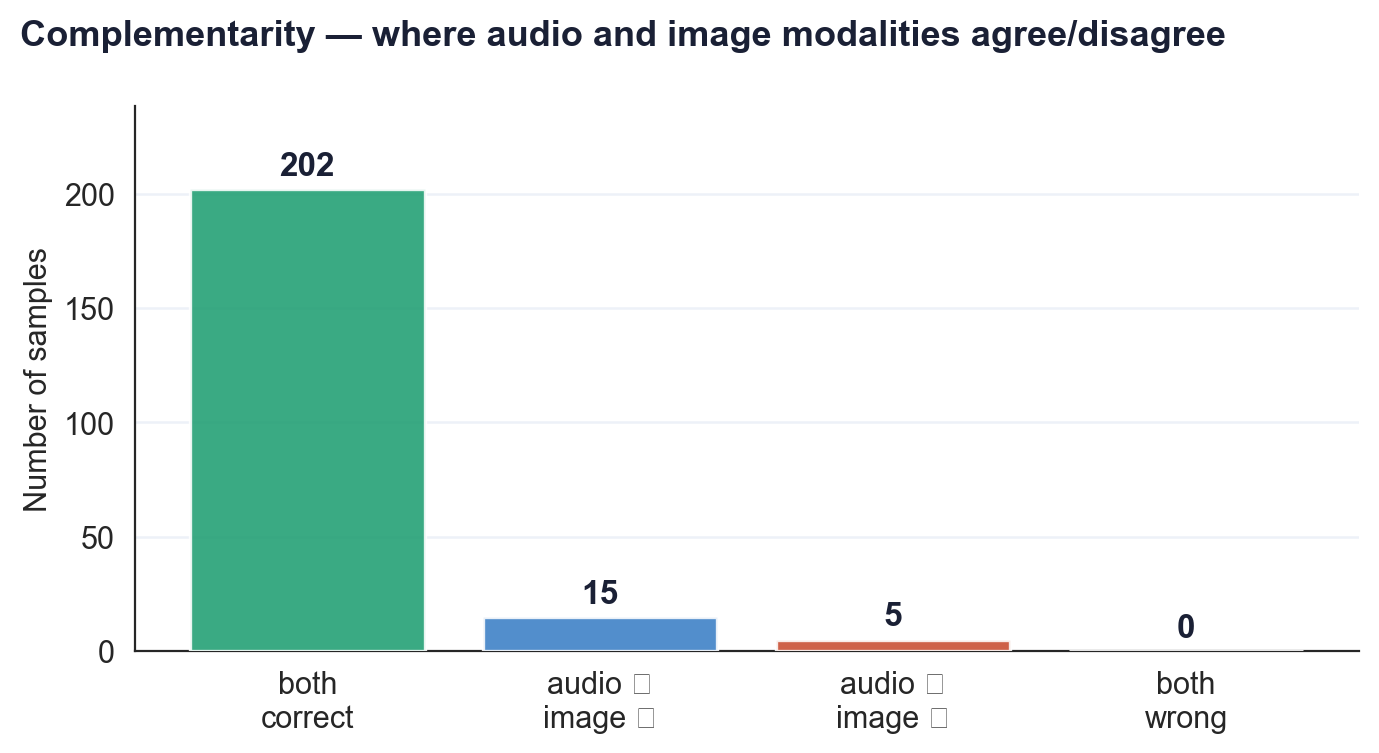

In [11]:
# ── Bar: complementarity breakdown ──────────────────────────────────────────
labels = ["both\ncorrect", "audio ✓\nimage ✗", "audio ✗\nimage ✓", "both\nwrong"]
counts = [cats[k] for k in ["both correct","audio ✓  image ✗","audio ✗  image ✓","both wrong"]]
colors = [P["target"], P["s01"], P["s02"], "black"]

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(labels, counts, color=colors, alpha=0.88, edgecolor="white", lw=1.2, zorder=3)
ax.yaxis.grid(True, color=P["grid"], lw=0.9, zorder=0); ax.set_axisbelow(True)

ymax = max(counts) * 1.18
ax.set_ylim(0, ymax)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, cnt + ymax*0.013,
            str(cnt), ha="center", va="bottom", fontsize=12, fontweight="bold",
            color=P["ink"])

ax.set_ylabel("Number of samples", fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.tick_params(bottom=False)

fig.suptitle("Complementarity — where audio and image modalities agree/disagree",
             x=0.02, ha="left", fontsize=13, fontweight="semibold", color=P["ink"])
fig.tight_layout()
plt.savefig(PROJ / "docs/figures/analysis_f_bar.png", dpi=150, bbox_inches="tight")
plt.show()
